<a href="https://colab.research.google.com/github/np03cs4s240161-dot/Concept-technology-of-AI/blob/main/Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
drive.mount('/content/drive')
base = ('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Problem1


##1

In [19]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

base = ('/content/drive/MyDrive/')
df = pd.read_csv(base + '/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("The info of the dataframe: ")
df.info()

print(" ")

print("The columns in the dataframe: ")
print(df.columns)

print(" ")

print("Description of the dataframe: ")
print(df.describe())

print(" ")

print("Checking null")
print(df.isnull().sum())

The info of the dataframe: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
 
The columns in the dataframe: 
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
 
Description of t

##2

In [20]:
columns_zero_checker = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_zero_checker:
  df[col] = df[col].replace(0, np.nan)

current_nulls = df.isnull().sum().sum()
if current_nulls > 0:
  print(f"found {current_nulls}")
  df.fillna(df.mean(), inplace=True)
  print("Should be fine now! :)")
else:
  print("No nulls found")






found 652
Should be fine now! :)


##3

In [ ]:
X = df.drop(columns=['Outcome']).values
Y = df['Outcome'].values

def train_test_split (X,Y,test_size = 0.3, random_seed = 40):
  """
  Split the dataset into training set and testing set.

  Parameters:
  X:Data, independent variable
  Y: Target , dependent variable
  test_size: size of the test set
  random_seed: seed for the random number generator

  Returns:
  XTrain, XTest, YTrain, YTest
    Training and Testing set of X and Y respectively
  """


  np.random.seed(random_seed)
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices)

  testsplit_size = int(len(X) * test_size)

  testIndices = indices[:testsplit_size]
  trainIndices = indices[testsplit_size:]
  XTrain, XTest = X[trainIndices], X[testIndices]
  YTrain, YTest = Y[trainIndices], Y[testIndices]
  return XTrain, XTest, YTrain, YTest

XTrain , XTest, YTrain, YTest = train_test_split(X,Y)

print("Shapes of Xtrain: ", XTrain.shape)
print("Shapes of Xtest: ", XTest.shape)
print("Shapes of Ytrain: ", YTrain.shape)
print("Shapes of Ytest: ", YTest.shape)

Shapes of Xtrain:  (538, 8)
Shapes of Xtest:  (230, 8)
Shapes of Ytrain:  (538,)
Shapes of Ytest:  (230,)


##4


In [ ]:
def euclidean_distance(pointy1,pointy2):
  """
  Calculates the eulidean distance between two points.
  Parameters:
  pointy1: first point pf numpy array
  pointy2: second point pf numpy array.
  Returns:
  distance: distance between the two points
  """
  distance = np.sqrt(np.sum((pointy1- pointy2) ** 2))
  return distance


In [ ]:
def KNN_predictingsingle(query,XTrain,YTrain,k=3):
  """
  Predicts the class of a single query.
  Parameters:
  query: query point
  XTrain: Training feature matrx.
  YTrain: Training label.

  k = number of neighbours.

  Returns:
  predicted label class.
  """
  distance = [euclidean_distance(query,x) for x in XTrain]
  sorted_distance_indices = np.argsort(distance)[:k]
  nearest_label = YTrain[sorted_distance_indices]
  prediction = np.bincount(nearest_label).argmax()
  return prediction

In [ ]:
def KNN_predict(XTrain,YTrain,XTest,k=3):
  """
  Predicts the class label for all test samples.
  Parameters:
  XTrain: Training feature matrx.
  YTrain: Training label.
  XTest: Testing feature matrix.
  k = number of neighbours.

  Returns:
  array of predicted labels.
  """

  predictions = [KNN_predictingsingle(x,XTrain,YTrain,k) for x in XTest]
  return np.array(predictions)


In [ ]:
def compute_accuracy(YTest,YPred):
  """
  Computes the accuracy of the model.
  Parameters:
  YTest: Testing label.
  YPred: Predicted label.

  Returns:
  accuracy as percent.
  """

  correct_predictions = np.sum(YTest == YPred)
  total_predictions = len(YTest)
  accuracy = correct_predictions / total_predictions *100
  return accuracy
try:
    predictions = KNN_predict(XTrain, YTrain, XTest, k=3)
    accuracy = compute_accuracy(YTest, predictions)
    print(f"Accuracy of the KNN model on the test set: {accuracy:.2f}%")
except Exception as e:
    print(f"An unexpected error occurred during prediction or accuracy computation: {e}")

Accuracy of the KNN model on the test set: 71.74%


#Problem2


In [ ]:
def scale(X):
  """
  Scales the matrix X.
  Parameters:
  X: matrix to be scaled.

  Returns:
  scaled matrix.
  """
  mean = np.mean(X, axis =0)
  std = np.std(X, axis =0)

  return (X - mean) / std

X_scaled = scale(X)
XTrain_s, XTest_s, YTrain_s, YTest_s = train_test_split(X_scaled,Y)

try:
  predictionScale = KNN_predict(XTrain_s,YTrain_s,XTest_s,k=3)
  accuracyScale = compute_accuracy(YTest_s, predictionScale)
  print(f"Accuracy: {accuracyScale:.2f}")
except Exception as e:
  print(f"An unexpected error occurred during prediction or accuracy computation: {e}")

Accuracy: 73.91


In [ ]:
print(f"Accuracy(original): {accuracy:.2f}")
print(f"Accuracy(scaled): {accuracyScale}")

Accuracy(original): 71.74
Accuracy(scaled): 73.91304347826086


Scaling increases the KNN perforamnce because KNN is a distance based algorithm. Scaling makes sure that all features are equal in contribution without one being dominant.


#Problem3

In [ ]:

k_values = range(1,16)

acc_original = []
time_original =[]

acc_scaled = []
time_scaled =[]

for k in k_values:
  start_time = time.time()
  predictions = KNN_predict(XTrain,YTrain,XTest,k=k)
  end_time = time.time()
  acc = compute_accuracy(YTest, predictions)
  acc_original.append(acc)

  time_original.append(end_time - start_time)

  start_time = time.time()
  prediction_scaled = KNN_predict(XTrain_s,YTrain_s,XTest_s,k=k)
  end_time = time.time()

  acc_s = compute_accuracy(YTest_s, prediction_scaled)
  acc_scaled.append(acc_s)
  time_scaled.append(end_time - start_time)

  print(f"k={k} Original Accuracy: {acc}, Scaled accuracy ={acc_s}")



k=1 Original Accuracy: 67.3913043478261, Scaled accuracy =66.52173913043478
k=2 Original Accuracy: 72.17391304347827, Scaled accuracy =66.52173913043478
k=3 Original Accuracy: 71.73913043478261, Scaled accuracy =73.91304347826086
k=4 Original Accuracy: 72.17391304347827, Scaled accuracy =72.60869565217392
k=5 Original Accuracy: 74.34782608695653, Scaled accuracy =76.52173913043478
k=6 Original Accuracy: 75.21739130434783, Scaled accuracy =73.04347826086956
k=7 Original Accuracy: 76.95652173913044, Scaled accuracy =74.78260869565217
k=8 Original Accuracy: 75.65217391304347, Scaled accuracy =74.78260869565217
k=9 Original Accuracy: 75.65217391304347, Scaled accuracy =73.04347826086956
k=10 Original Accuracy: 73.91304347826086, Scaled accuracy =72.60869565217392
k=11 Original Accuracy: 74.78260869565217, Scaled accuracy =72.60869565217392
k=12 Original Accuracy: 74.78260869565217, Scaled accuracy =70.86956521739131
k=13 Original Accuracy: 75.65217391304347, Scaled accuracy =73.47826086956

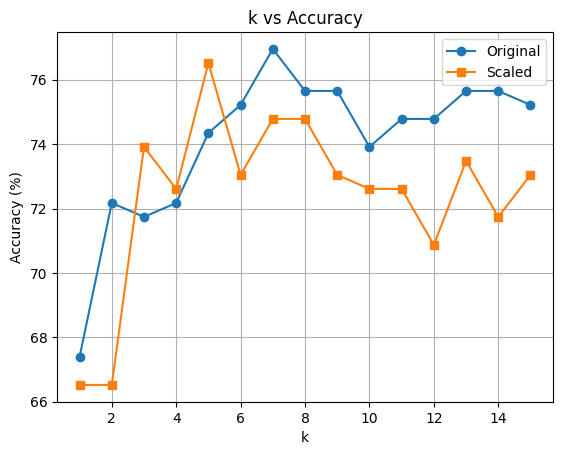

In [ ]:
plt.figure()
plt.plot(k_values, acc_original,marker ='o', label="Original")
plt.plot(k_values, acc_scaled,marker ='s', label="Scaled")
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("k vs Accuracy")
plt.legend()
plt.grid()
plt.show()

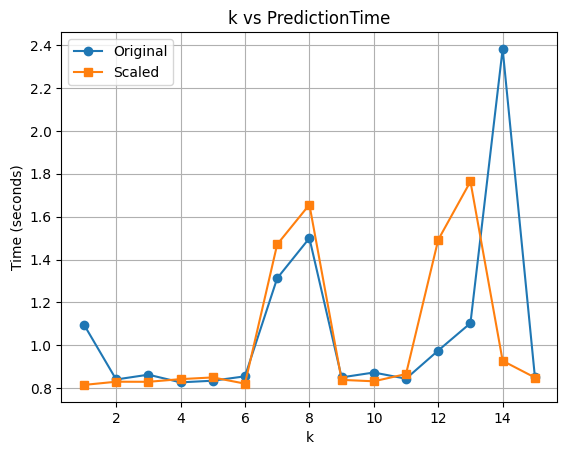

In [ ]:
plt.figure()
plt.plot(k_values, time_original,marker ='o', label="Original")
plt.plot(k_values, time_scaled,marker ='s', label="Scaled")
plt.xlabel("k")
plt.ylabel("Time (seconds)")
plt.title("k vs PredictionTime")
plt.legend()
plt.grid()
plt.show()